In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
# 1. Load the Master Model
model = joblib.load('C:/Users/Sam Garcia/PycharmProjects/macro_alpha/models/macro_xgb_model.joblib')

In [3]:
# 2. Load the Inference Data (The data where we DIDN'T drop the last 5 rows)
df_inference = pd.read_parquet('C:/Users/Sam Garcia/PycharmProjects/macro_alpha/data/processed/inference_ready_features.parquet')
X_inference = df_inference.drop(columns=['target_5d_up'])

In [4]:
# 3. Grab "Today" (The very last row in our dataset)
X_today = X_inference.iloc[-1:]
today_date = X_today.index[0].date()

print(f"Generating SHAP explanation for market conditions on: {today_date}")

Generating SHAP explanation for market conditions on: 2026-02-06


In [5]:
# 4. Create the SHAP Explainer
# TreeExplainer is heavily optimized for XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for today
shap_values = explainer(X_today)

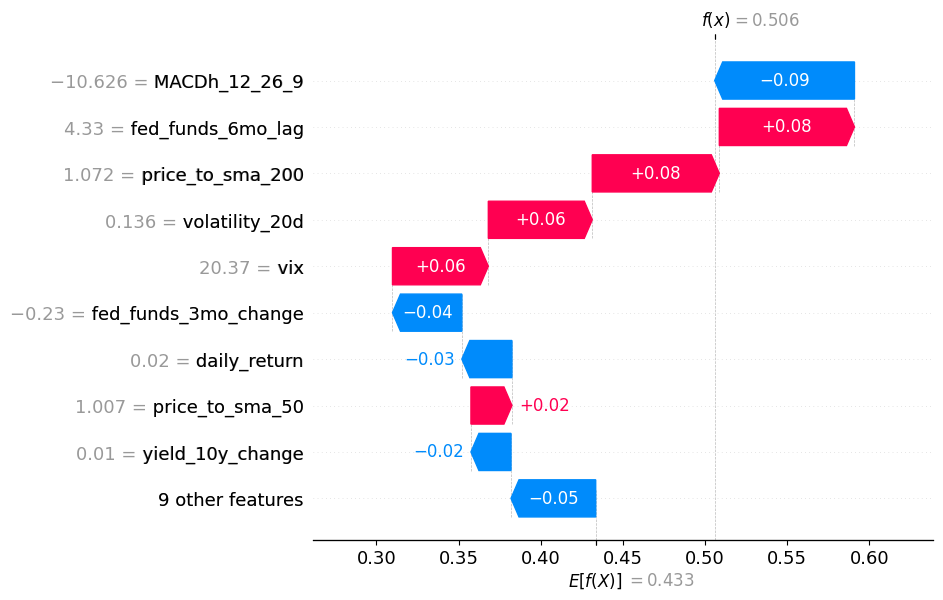

<Figure size 640x480 with 0 Axes>


Model Confidence for an UP move: 62.38%


In [6]:
# 5. Generate the Waterfall Plot
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_values[0], max_display=10)
plt.tight_layout()
plt.show()

# Print the actual probability for context
prob_up = model.predict_proba(X_today)[0][1]
print(f"\nModel Confidence for an UP move: {prob_up:.2%}")